# 🔁 Recurrent Neural Networks (RNNs) — The Complete Deep-Dive

**Topics covered (in order):**
1. Failure of Dense networks & why we need RNNs
2. What IS an RNN — definition, intuition, unrolling
3. The three weight matrices (components)
4. Step-by-step forward-pass computation (numerical trace)
5. Architecture taxonomy (One-to-One through Many-to-Many)
6. Uni-directional vs Bi-directional RNN
7. Backpropagation Through Time (BPTT)
8. Full worked application — Sentiment Analysis
9. Issues in RNN + mathematical proofs
10. Visualisations for every concept
11. Interview Q&A


In [18]:
import os
from PIL import Image

notebook_dir = os.path.abspath('')

## 1. 🧱 Why Dense / MLP Networks Fail on Sequences

### 1.1 The Fixed-Size Problem
A standard fully-connected (Dense / MLP) network takes a **fixed-size vector** as input.  
- "Good" → 1 word → pad to length 10 → `[tok, 0, 0, 0, 0, 0, 0, 0, 0, 0]`  
- "The movie was absolutely breathtaking and beautiful" → 7 words → fits  
- "The film, directed by the award-winning Christopher Nolan, is …"  → 100+ words → **truncated → information lost**

You can pick a very large fixed size, but you waste memory on short sentences AND you still have an upper limit.

### 1.2 The No-Memory / No-Order Problem
Imagine a Dense network reading the word IDs `[4, 9, 2]` for "dog bites man" and `[2, 9, 4]` for "man bites dog".  
To a Dense layer, these **look the same** after a global pooling — both contain word IDs 2, 4, 9.  
**Order is destroyed** by the matrix multiply of a flat input vector.

### 1.3 The Context Problem
"I grew up in France … I speak fluent ___"  
The blank is "French" — but the clue ("France") is 8 words earlier.  
A Dense network has **no mechanism** to carry that context forward.

> **Summary table**
> | Problem | Dense Network | RNN |
> |---|---|---|
> | Variable-length input | ❌ Requires padding to fixed size | ✅ Processes any length |
> | Word order / sequence order | ❌ Treats input as a bag | ✅ Steps through in order |
> | Long-range context | ❌ No memory across positions | ✅ Hidden state carries context |


## 2. 🔄 What IS a Recurrent Neural Network?

### Definition
An **RNN** is a neural network that has a **feedback loop**: the output (hidden state) from one time step is fed back as an additional input to the next time step.

$$
h_t = f(U \cdot x_t + V \cdot h_{t-1} + b_h)
$$

$$
o_t = W \cdot h_t + b_y
$$

where:
- `x_t`     = input vector at time step t
- `h_t`     = hidden state at time t  (the "memory")
- `h_{t-1}` = hidden state from previous step
- `o_t`     = output at time t
- `f`       = non-linear activation (usually `tanh`)


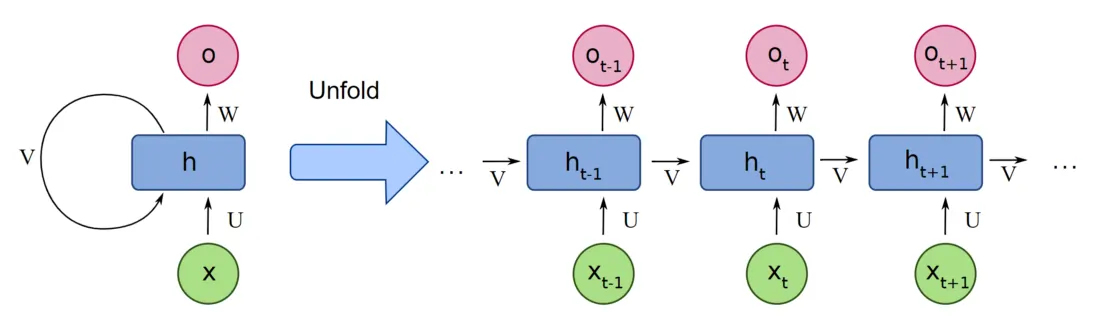

In [19]:
img_path = os.path.join(notebook_dir, r"assets\08_rnn\rnn_initial.webp")

# Load and show
try:
    img = Image.open(img_path)
    display(img)
except FileNotFoundError:
    print(f"Error: Could not find image at {img_path}")


### The Unrolling Intuition
The same network (same weights) is **applied repeatedly** — once per time step.  
We can "unroll" this loop in time to visualise it as a deep network where every layer shares weights:

```
x1 ──► [RNN cell] ──h1──► [RNN cell] ──h2──► [RNN cell] ──h3──► Output
                 ↑                   ↑                   ↑
              (same V)            (same V)            (same V)
```

Key insight: **weight sharing across time** means:
- Fewer parameters than a full sequence-length network
- BUT also the source of vanishing/exploding gradients (covered in Section 9)

### The "Reading a Book" Analogy
Think of an RNN as a **person reading a book word by word**:
- `x_t` = the word they just read
- `h_{t-1}` = their "working memory" of everything read so far
- `h_t` = updated memory after reading the current word
- `y_t` = their guess/answer at this moment

The same brain (same weights `V`) is used to process every single word.


## 3. ⚙️ Components of an RNN — The Three Weight Matrices

An RNN cell has exactly **three learnable weight matrices** and **two bias vectors**:

| Parameter | Shape | Role |
|---|---|---|
| `U` | `[hidden_dim, input_dim]` | Maps **current input** → hidden state |
| `V` | `[hidden_dim, hidden_dim]` | Maps **previous hidden state** → current hidden state |
| `b_h`  | `[hidden_dim]`            | Hidden state bias |
| `W` | `[output_dim, hidden_dim]`| Maps **hidden state** → output |
| `b_y`  | `[output_dim]`            | Output bias |

### The Full Equations
$$h_t = \tanh(U \cdot x_t + V \cdot h_{t-1} + b_h)$$
$$o_t = W \cdot h_t + b_y$$

### Why `tanh` as activation?
- Output is bounded in `[-1, 1]` — prevents values from growing unboundedly
- Zero-centered — gradients can be positive or negative  
- **Downside:** derivative `sech²(z)` is always `≤ 1` — contributes to vanishing gradients  

### Total Parameter Count
For input_dim=10, hidden_dim=32, output_dim=1:
- `U` = 10 × 32 = 320
- `V` = 32 × 32 = 1024  ← **dominant term**
- `W` = 32 × 1  = 32
- Biases = 32 + 1  = 33
- **Total = 1,409 parameters** (regardless of sequence length!)


In [20]:
import numpy as np

np.random.seed(42)
np.set_printoptions(precision=4, suppress=True)

# ── Tiny RNN: input_dim=3, hidden_dim=4, output_dim=1 ──
input_dim, hidden_dim, output_dim = 3, 4, 1

U = np.random.randn(hidden_dim, input_dim) * 0.5
V = np.random.randn(hidden_dim, hidden_dim) * 0.5
b_h  = np.zeros(hidden_dim)
W = np.random.randn(output_dim, hidden_dim) * 0.5
b_y  = np.zeros(output_dim)

# ── Sentence: "I love dogs" → word embeddings (3-dim for demo) ──
# In real life these come from an Embedding layer
x1 = np.array([0.8, 0.1, 0.2])   # "I"
x2 = np.array([0.3, 0.9, 0.4])   # "love"
x3 = np.array([0.1, 0.2, 0.95])  # "dogs"

sentence = [("I",    x1),
            ("love", x2),
            ("dogs", x3)]

h_prev = np.zeros(hidden_dim)      # h0 = zero vector

print("=" * 60)
print("STEP-BY-STEP RNN FORWARD PASS")
print("Sentence: 'I love dogs'  |  Many-to-One (sentiment)")
print("=" * 60)

for t, (word, x_t) in enumerate(sentence, 1):
    # ── Core equation ──
    z_t = U @ x_t + V @ h_prev + b_h
    h_t = np.tanh(z_t)

    print(f"\n── Step {t}: word = '{word}' ──")
    print(f"  x_{t}        = {x_t}")
    print(f"  h_{t-1} (prev) = {h_prev.round(4)}")
    print(f"  U·x_{t}  = {(U @ x_t).round(4)}")
    print(f"  V·h_{{t-1}}= {(V @ h_prev).round(4)}")
    print(f"  z_{t} (pre-tanh) = {z_t.round(4)}")
    print(f"  h_{t} (tanh)     = {h_t.round(4)}")

    h_prev = h_t

# ── Final prediction (many-to-one: use last hidden state) ──
y_hat = W @ h_prev + b_y
prob  = 1 / (1 + np.exp(-y_hat[0]))   # sigmoid

print("\n" + "=" * 60)
print("FINAL OUTPUT (Many-to-One)")
print(f"  h_3 (final memory) = {h_prev.round(4)}")
print(f"  W·h_3 + b_y     = {y_hat[0]:.4f}")
print(f"  Sentiment score (σ) = {prob:.4f}  →  {'Positive 😊' if prob > 0.5 else 'Negative 😢'}")
print("=" * 60)


STEP-BY-STEP RNN FORWARD PASS
Sentence: 'I love dogs'  |  Many-to-One (sentiment)

── Step 1: word = 'I' ──
  x_1        = [0.8 0.1 0.2]
  h_0 (prev) = [0. 0. 0. 0.]
  U·x_1  = [0.2565 0.5741 0.6231 0.1473]
  V·h_{t-1}= [0. 0. 0. 0.]
  z_1 (pre-tanh) = [0.2565 0.5741 0.6231 0.1473]
  h_1 (tanh)     = [0.2511 0.5184 0.5533 0.1462]

── Step 2: word = 'love' ──
  x_2        = [0.3 0.9 0.4]
  h_1 (prev) = [0.2511 0.5184 0.5533 0.1462]
  U·x_2  = [ 0.1418  0.0763  0.4883 -0.2203]
  V·h_{t-1}= [-0.9838 -0.4001  0.04   -0.3305]
  z_2 (pre-tanh) = [-0.842  -0.3239  0.5283 -0.5508]
  h_2 (tanh)     = [-0.6869 -0.313   0.4841 -0.5011]

── Step 3: word = 'dogs' ──
  x_3        = [0.1  0.2  0.95]
  h_2 (prev) = [-0.6869 -0.313   0.4841 -0.5011]
  U·x_3  = [ 0.3187 -0.0585 -0.0673 -0.2404]
  V·h_{t-1}= [-0.0603  0.4328 -0.0947 -0.2031]
  z_3 (pre-tanh) = [ 0.2584  0.3743 -0.162  -0.4436]
  h_3 (tanh)     = [ 0.2528  0.3577 -0.1606 -0.4166]

FINAL OUTPUT (Many-to-One)
  h_3 (final memory) = [ 0.2528

## 4. 🏛️ RNN Architecture Taxonomy

Not all sequence problems have the same input→output shape. RNNs handle **five** canonical patterns:

| Type | Input | Output | Example |
|---|---|---|---|
| **One-to-One** | Single vector | Single vector | Plain MLP (no sequence) |
| **One-to-Many** | Single vector | Sequence | Image → Caption (Image Captioning) |
| **Many-to-One** | Sequence | Single vector | Sentence → Positive/Negative (Sentiment) |
| **Many-to-Many (sync)** | Sequence | Sequence (same length) | POS tagging, NER |
| **Many-to-Many (async)** | Sequence | Sequence (diff length) | Machine Translation (Encoder-Decoder) |

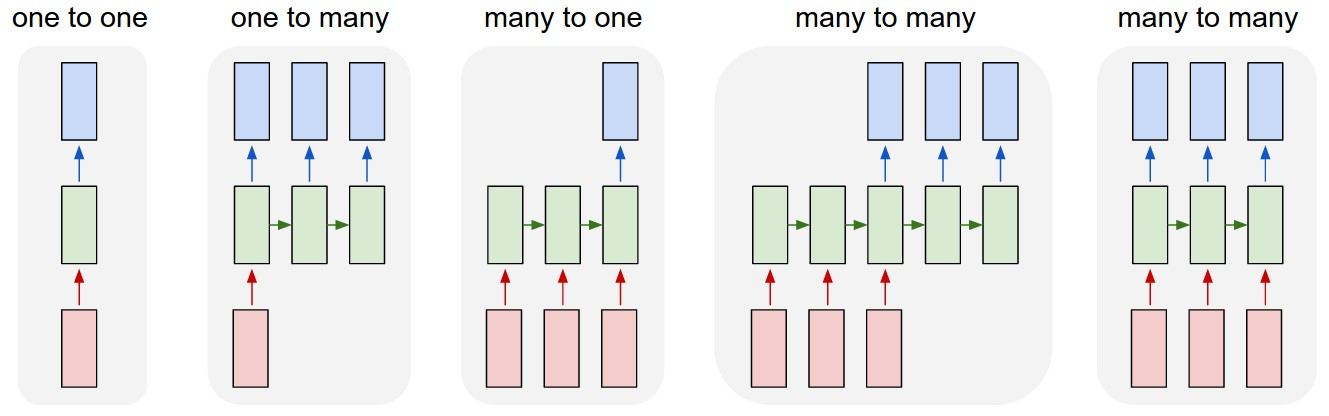

In [21]:
img_path = os.path.join(notebook_dir, r"assets\08_rnn\rnn_versions.jpeg")

# Load and show
try:
    img = Image.open(img_path)
    display(img)
except FileNotFoundError:
    print(f"Error: Could not find image at {img_path}")

## 5. ↔️ Uni-directional vs Bi-directional RNN

### Uni-directional (Standard)
- Reads the sequence **left → right** only
- At each step `t`, the hidden state `h_t` only has access to words `x_1 … x_t`
- **Cannot see the future**

**Best for:**
- Real-time / streaming data (speech-to-text, live translation)
- Time-series forecasting (you cannot use future stock prices to predict today's)
- Text generation (auto-regressive — next word depends only on past)

### Bi-directional RNN
Runs **two** RNN layers simultaneously:
- Forward RNN: reads `x_1 → x_2 → … → x_T`  (left to right)
- Backward RNN: reads `x_T → x_{T-1} → … → x_1`  (right to left)

At each position `t`, the final representation is:
$$H_t = [\overrightarrow{h}_t \; ; \; \overleftarrow{h}_t]$$
(concatenation of both directions — doubles the hidden dimension)

**Best for:**
- Tasks where **full sentence context** is available at inference time
- Sentiment Analysis, Named Entity Recognition, POS tagging
- BERT uses Bidirectional Transformers — same philosophy

**Cannot use for:**
- Real-time inference (you need the full sequence before processing)
- Language modelling / text generation (would cheat by seeing future words)

### Example: Why future context matters
```
"The crane [flew / lifted] …"
```
Without future context, "crane" is ambiguous (bird or machine?).  
A bidirectional RNN resolves this by reading both directions before classifying.


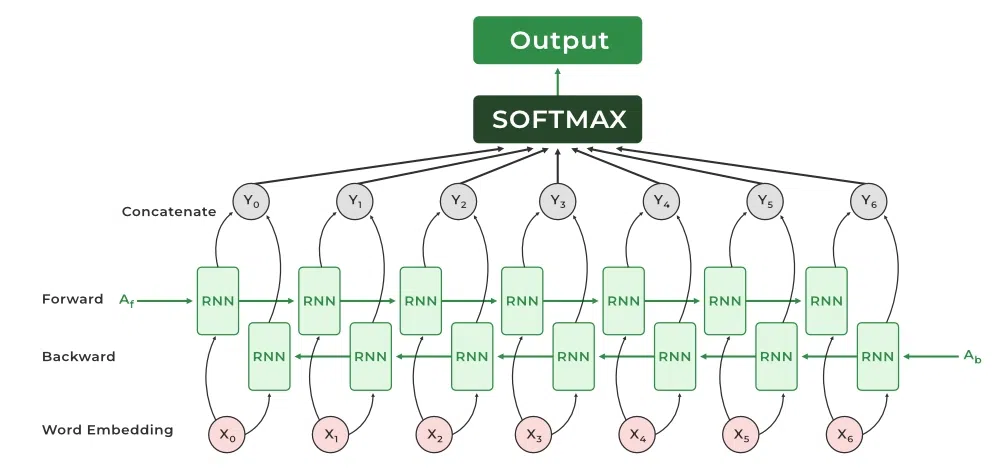

In [22]:
img_path = os.path.join(notebook_dir, r"assets\08_rnn\bi_rnn.webp")

# Load and show
try:
    img = Image.open(img_path)
    display(img)
except FileNotFoundError:
    print(f"Error: Could not find image at {img_path}")

#### Backpropagation Through Time (BPTT) in RNN

Training a Recurrent Neural Network requires computing gradients of the loss with respect to the model parameters.  
Unlike feedforward networks, an RNN **reuses the same parameters across multiple time steps**, which means the gradient must flow **through time as well as through layers**.

This process is called **Backpropagation Through Time (BPTT)**.

#### 1. Forward Pass

During the forward pass, the model processes the input sequence **one timestep at a time**.

At each timestep the RNN:

1. Combines the **current input** with the **previous hidden state**
2. Computes a new hidden state
3. Produces an output

Hidden state computation:

$$
z_t = Ux_t + Vh_{t-1} + b_h
$$

$$
h_t = \tanh(z_t)
$$

Output layer:

$$
o_t = Wh_t + b_y
$$

Where:

- $x_t$ = input at time $t$
- $h_t$ = hidden state
- $U$ = input → hidden weights
- $V$ = hidden → hidden (recurrent) weights
- $W$ = hidden → output weights

The hidden state acts as the **memory of the network**, allowing the model to capture temporal dependencies.

#### 2. Loss Over the Entire Sequence

The RNN typically produces an output at each timestep.  
The total loss is therefore the **sum of losses across all timesteps**.

$$
L = \sum_{t=1}^{T} L_t
$$

where

$$
L_t = \mathcal{L}(y_t, \hat{y}_t)
$$

This means the model must learn parameters that minimize the **total sequence loss**, not just the loss at a single step.

#### 3. Goal of Backpropagation

Training requires computing gradients:

$$
\frac{\partial L}{\partial U}, \quad
\frac{\partial L}{\partial V}, \quad
\frac{\partial L}{\partial W}
$$

Because the **same parameters are reused at every timestep**, the gradient must accumulate contributions from **all timesteps**.

Example:

$$
\frac{\partial L}{\partial V} =
\sum_{t=1}^{T}
\frac{\partial L_t}{\partial V}
$$

This means the update to the recurrent weights depends on **every timestep in the sequence**.

#### 4. Backpropagation from the Output Layer

The output is

$$
o_t = Wh_t + b_y
$$

Using the chain rule:

$$
\frac{\partial L}{\partial W} =
\sum_{t=1}^{T}
\frac{\partial L}{\partial o_t} h_t^T
$$

Each timestep contributes to the gradient of \(W\).

Bias gradient:

$$
\frac{\partial L}{\partial b_y} =
\sum_{t=1}^{T}
\frac{\partial L}{\partial o_t}
$$

#### 5. Gradient with Respect to Hidden State

The hidden state influences the loss in **two ways**:

1. It directly affects the output at time \(t\)
2. It affects **future hidden states**

Therefore the gradient becomes recursive:

$$
\frac{\partial L}{\partial h_t} =
W^T \frac{\partial L}{\partial o_t}
+
\frac{\partial L}{\partial h_{t+1}}
\frac{\partial h_{t+1}}{\partial h_t}
$$

This equation explains why gradients must propagate **backwards through time**.

#### 6. Gradient Through the Activation Function

Hidden activation:

$$
h_t = \tanh(z_t)
$$

Derivative of tanh:

$$
\frac{d}{dz}\tanh(z) = 1 - \tanh^2(z)
$$

Thus

$$
\frac{\partial h_t}{\partial z_t} =
1 - h_t^2
$$

Define the **error signal**

$$
\delta_t = \frac{\partial L}{\partial z_t}
$$

Then

$$
\delta_t =
\frac{\partial L}{\partial h_t}
\odot (1 - h_t^2)
$$

where \( \odot \) denotes element-wise multiplication.

#### 7. Gradients of the Parameters

#### Gradient of \(W\)

$$
\frac{\partial L}{\partial W} =
\sum_{t=1}^{T}
\frac{\partial L}{\partial o_t} h_t^T
$$

#### Gradient of \(V\) (recurrent weights)

Hidden state equation:

$$
z_t = Ux_t + Vh_{t-1}
$$

Gradient:

$$
\frac{\partial L}{\partial V}
=
\sum_{t=1}^{T}
\delta_t h_{t-1}^T
$$

This shows that the gradient depends on the **previous hidden state**.

## Gradient of \(U\)

Input weights:

$$
\frac{\partial L}{\partial U}
=
\sum_{t=1}^{T}
\delta_t x_t^T
$$

#### Gradient of hidden bias

$$
\frac{\partial L}{\partial b_h}
=
\sum_{t=1}^{T}
\delta_t
$$

#### 8. Gradient Flow Through Time

The hidden state depends on the previous hidden state:

$$
h_t = \tanh(Ux_t + Vh_{t-1})
$$

Applying the chain rule:

$$
\frac{\partial h_t}{\partial h_{t-1}}
=
\frac{\partial h_t}{\partial z_t}
\frac{\partial z_t}{\partial h_{t-1}}
$$

$$
=
\text{diag}(1 - h_t^2) V
$$

If we propagate from time \(T\) back to time \(k\):

$$
\frac{\partial h_T}{\partial h_k}
=
\prod_{i=k+1}^{T}
\text{diag}(1 - h_i^2) V
$$

This becomes a **product of many matrices**, which is the root cause of gradient instability.

#### 9. Final BPTT Recursion

The recursive error signal becomes:

$$
\delta_t =
\left(
W^T \frac{\partial L}{\partial o_t}
+
V^T \delta_{t+1}
\right)
\odot (1 - h_t^2)
$$

This equation is the **core update rule used in BPTT**.

#### 10. Vanishing and Exploding Gradients

Because gradients involve repeated matrix multiplications:

$$
\prod_{i=k+1}^{T}
\text{diag}(1-h_i^2) V
$$

two problems can occur.

#### Vanishing gradients

If eigenvalues of \(V\) are smaller than 1:

$$
||V|| < 1
$$

the gradient shrinks exponentially.

#### Exploding gradients

If eigenvalues are larger than 1:

$$
||V|| > 1
$$

the gradient grows exponentially.

#### 7. 🚨 Major Issues in Vanilla RNNs (With Mathematical Explanation)

Although RNNs are designed to model sequential data, in practice they suffer from several fundamental training difficulties.  
The two most important are **vanishing gradients** and **exploding gradients**, which arise from repeatedly applying the same transformation across many time steps.

#### Issue 1: Vanishing Gradient

#### Intuition

During training, gradients must propagate **backwards through many time steps**.

If the gradient shrinks at each step, by the time it reaches earlier time steps it becomes **almost zero**, meaning those parameters receive **no meaningful updates**.

As a result, the network **cannot learn long-range dependencies**.

#### Mathematical Explanation

The hidden state of a simple RNN is

$$
h_t = \tanh(Ux_t + Vh_{t-1})
$$

During backpropagation we compute

$$
\frac{\partial h_T}{\partial h_k} =
\prod_{i=k+1}^{T}
\frac{\partial h_i}{\partial h_{i-1}}
$$

Using the chain rule:

$$
\frac{\partial h_i}{\partial h_{i-1}} =
\text{diag}(1 - h_i^2)V
$$

Therefore

$$
\frac{\partial h_T}{\partial h_k} =
\prod_{i=k+1}^{T}
\text{diag}(1-h_i^2)V
$$

This is a **product of many matrices**, which determines how the gradient behaves.

#### Simplified Scalar Case (Proof)

For intuition, assume a scalar hidden state and ignore the activation.

$$
h_t = Vh_{t-1}
$$

Then

$$
\frac{\partial h_T}{\partial h_k} = V^{T-k}
$$

#### Case 1 — Vanishing

If

$$
|V| < 1
$$

then

$$
V = 0.9,\quad T-k = 50
$$

$$
0.9^{50} \approx 0.005
$$

The gradient reaching step \(k\) becomes **200× smaller**.

Thus early time steps receive **almost no learning signal**.

#### Effect of the Activation Function

In practice we use **tanh**.

$$
\tanh'(z) = 1 - \tanh^2(z)
$$

and

$$
0 \leq \tanh'(z) \leq 1
$$

Therefore each step multiplies the gradient by a value **≤ 1**, making the gradient shrink **even faster**.

#### Full Vector Case (Jacobian Analysis)

For vector hidden states:

$$
\left\|
\frac{\partial h_T}{\partial h_k}
\right\|
\le
\prod_{i=k+1}^{T}
\|
\text{diag}(1-h_i^2)
\|
\cdot
\|V\|
$$

Since

$$
\|
\text{diag}(1-h_i^2)
\| \le 1
$$

we get

$$
\left\|
\frac{\partial h_T}{\partial h_k}
\right\|
\le
(\lambda_{\max}(V))^{T-k}
$$

where
$$
\( \lambda_{\max}(V) \) = largest eigenvalue of \(V\).
$$
If

$$
\lambda_{\max}(V) < 1
$$

the gradient **vanishes exponentially**.

#### Why This Matters (Practical Consequences)

The model learns **short-term dependencies only**.

Example:

> “The animal didn’t cross the street because **it** was too tired.”

To understand **“it”**, the model must remember **“animal”** many words earlier.

Vanilla RNNs struggle with this because the gradient signal **dies before reaching earlier words**.

#### Issue 2: Exploding Gradient

#### Intuition

The opposite problem occurs when gradients **grow exponentially** during backpropagation.

Instead of shrinking, they become extremely large and cause unstable weight updates.

#### Mathematical Explanation

From the simplified scalar case:

$$
\frac{\partial h_T}{\partial h_k} = V^{T-k}
$$

If

$$
|V| > 1
$$

then gradients grow rapidly.

Example:

$$
V = 1.1,\quad T-k = 100
$$

$$
1.1^{100} \approx 13780
$$

This produces **huge gradients**, which cause:

- unstable training
- numerical overflow
- large destructive parameter updates

#### Solution: Gradient Clipping

A common practical solution is **gradient clipping**.

If the gradient norm exceeds a threshold:

$$
\|g\| > \theta
$$

we rescale it:

$$
g \leftarrow \frac{\theta}{\|g\|} g
$$

Typical threshold:

$$
\theta \approx 1 \text{ to } 5
$$

This prevents extremely large updates.

#### Issue 3: Short-Term Memory (Information Overwrite)

In vanilla RNNs the hidden state update is

$$
h_t = \tanh(Vh_{t-1} + Ux_t)
$$

At each step, the hidden state is **completely recomputed**.

This creates two problems:

1. New inputs may **overwrite old information**
2. The network has **no mechanism to decide what to remember or forget**

Therefore RNNs struggle with tasks that require **long-term memory**.

Example:

- language translation
- long documents
- long time-series signals

#### Solution

Architectures like **LSTM** and **GRU** introduce **gating mechanisms** that control:

- what information to keep
- what information to forget
- what information to update

This greatly improves long-range memory.

#### Issue 4: Sequential Computation (Lack of Parallelism)

RNN computation follows the recurrence:

$$
h_t = f(x_t, h_{t-1})
$$

This means:

- step \(t\) cannot be computed until step \(t-1\) finishes.

As a result:

- time steps must be processed **sequentially**
- GPUs cannot parallelize computation across the sequence dimension.

#### Impact

Training becomes **slow for long sequences**.

This limitation motivated the development of **attention-based architectures**.


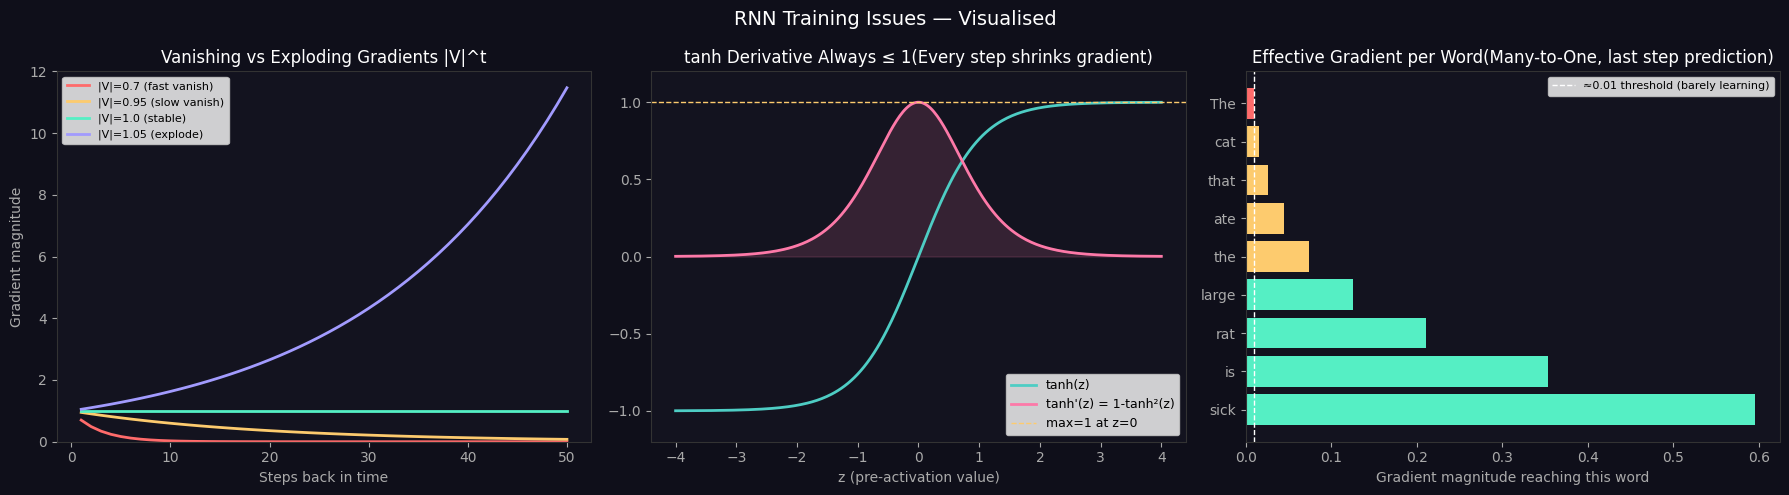

Saved → notes/assets/rnn_issues.png


In [25]:
import numpy as np
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.patch.set_facecolor('#0f0f1a')
fig.suptitle("RNN Training Issues — Visualised", color='white', fontsize=14)

# ── Plot 1: Vanishing vs Exploding gradient ──
ax = axes[0]
ax.set_facecolor('#13131f')
steps = np.arange(1, 51)

for w, lbl, col in [(0.7, '|V|=0.7 (fast vanish)', '#ff6b6b'),
                     (0.95,'|V|=0.95 (slow vanish)','#fdcb6e'),
                     (1.0, '|V|=1.0 (stable)',      '#55efc4'),
                     (1.05,'|V|=1.05 (explode)',     '#a29bfe')]:
    grads = w ** steps
    ax.plot(steps, np.clip(grads, 0, 20), label=lbl, color=col, lw=2)

ax.set_xlabel("Steps back in time", color='#aaa')
ax.set_ylabel("Gradient magnitude", color='#aaa')
ax.set_title("Vanishing vs Exploding Gradients |V|^t", color='white')
ax.legend(fontsize=8)
ax.tick_params(colors='#aaa')
ax.set_ylim(0, 12)
for sp in ax.spines.values(): sp.set_color('#333')

# ── Plot 2: tanh derivative shrinkage ──
ax = axes[1]
ax.set_facecolor('#13131f')
z = np.linspace(-4, 4, 300)
tanh_deriv = 1 - np.tanh(z)**2
ax.plot(z, np.tanh(z), color='#4ecdc4', lw=2, label='tanh(z)')
ax.plot(z, tanh_deriv,  color='#fd79a8', lw=2, label="tanh'(z) = 1-tanh²(z)")
ax.axhline(1, color='#fdcb6e', lw=1, ls='--', label='max=1 at z=0')
ax.fill_between(z, tanh_deriv, 0, alpha=0.15, color='#fd79a8')
ax.set_title("tanh Derivative Always ≤ 1(Every step shrinks gradient)", color='white')
ax.set_xlabel("z (pre-activation value)", color='#aaa')
ax.legend(fontsize=9)
ax.tick_params(colors='#aaa')
ax.set_ylim(-1.2, 1.2)
for sp in ax.spines.values(): sp.set_color('#333')

# ── Plot 3: Effect on "memory" at different distances ──
ax = axes[2]
ax.set_facecolor('#13131f')
words = ['The','cat','that','ate','the','large','rat','is','sick']
distances = np.arange(len(words), 0, -1)   # distance from prediction
# gradient reaching each position (|V|=0.85, tanh shrink≈0.5 per step)
effective_grad = (0.85 * 0.7) ** distances

colors_bar = ['#ff6b6b' if g < 0.01 else '#fdcb6e' if g < 0.1 else '#55efc4'
              for g in effective_grad]
bars = ax.barh(words[::-1], effective_grad[::-1], color=colors_bar[::-1])
ax.axvline(0.01, color='white', ls='--', lw=1, label='≈0.01 threshold (barely learning)')
ax.set_title('Effective Gradient per Word(Many-to-One, last step prediction)', color='white')
ax.set_xlabel('Gradient magnitude reaching this word', color='#aaa')
ax.legend(fontsize=8)
ax.tick_params(colors='#aaa')
for sp in ax.spines.values(): sp.set_color('#333')

plt.tight_layout()
# plt.savefig('notes/assets/rnn_issues.png', dpi=150, bbox_inches='tight', facecolor='#0f0f1a')
plt.show()
print("Saved → notes/assets/rnn_issues.png")


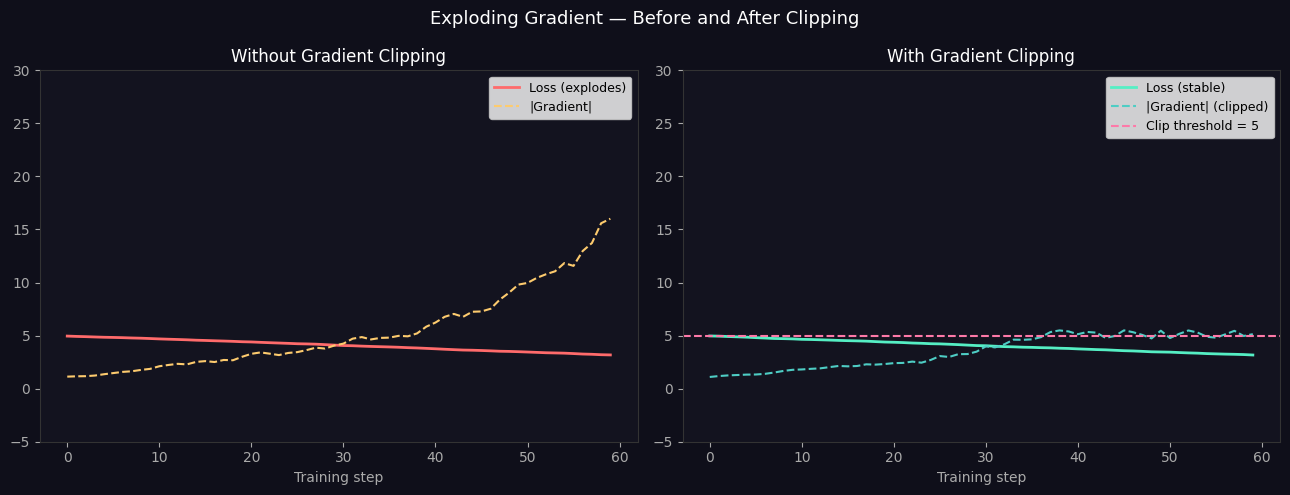

In [27]:
import numpy as np
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.patch.set_facecolor('#0f0f1a')

# ── Simulate training WITHOUT clipping ──
np.random.seed(7)
def simulate_rnn_training(clip=False, threshold=5.0, steps=60):
    V = 1.05   # slightly > 1 → exploding regime (V is the recurrent weight)
    losses = []
    grads  = []
    grad   = 1.0
    loss   = 5.0
    for _ in range(steps):
        grad *= V + np.random.normal(0, 0.05)
        grads.append(abs(grad))
        if clip and abs(grad) > threshold:
            grad = threshold * np.sign(grad)
        loss -= 0.03 * grad / (abs(grad) + 1e-6) * np.random.uniform(0.5, 1.5)
        losses.append(loss)
    return losses, grads

loss_no_clip, grad_no_clip = simulate_rnn_training(clip=False)
loss_clipped, grad_clipped = simulate_rnn_training(clip=True, threshold=5.0)

for ax, title, (l1, l2, g1, g2) in zip(axes,
    ["Without Gradient Clipping", "With Gradient Clipping (threshold=5)"],
    [([loss_no_clip, loss_clipped, grad_no_clip, grad_no_clip]),
     ([loss_clipped, loss_clipped, grad_clipped, grad_clipped])]):
    ax.set_facecolor('#13131f')

axes[0].set_facecolor('#13131f')
axes[0].plot(loss_no_clip, color='#ff6b6b', lw=2, label='Loss (explodes)')
axes[0].plot(grad_no_clip, color='#fdcb6e', lw=1.5, ls='--', label='|Gradient|')
axes[0].set_title('Without Gradient Clipping', color='white')
axes[0].set_xlabel('Training step', color='#aaa')
axes[0].legend(fontsize=9); axes[0].tick_params(colors='#aaa')
axes[0].set_ylim(-5, 30)
for sp in axes[0].spines.values(): sp.set_color('#333')

axes[1].set_facecolor('#13131f')
axes[1].plot(loss_clipped, color='#55efc4', lw=2, label='Loss (stable)')
axes[1].plot(grad_clipped, color='#4ecdc4', lw=1.5, ls='--', label='|Gradient| (clipped)')
axes[1].axhline(5.0, color='#fd79a8', ls='--', lw=1.5, label='Clip threshold = 5')
axes[1].set_title('With Gradient Clipping', color='white')
axes[1].set_xlabel('Training step', color='#aaa')
axes[1].legend(fontsize=9); axes[1].tick_params(colors='#aaa')
axes[1].set_ylim(-5, 30)
for sp in axes[1].spines.values(): sp.set_color('#333')

plt.suptitle("Exploding Gradient — Before and After Clipping", color='white', fontsize=13)
plt.tight_layout()
# plt.savefig('notes/assets/gradient_clipping.png', dpi=150, bbox_inches='tight', facecolor='#0f0f1a')
plt.show()


## 8. 🛠️ End-to-End Application: Sentiment Analysis (Many-to-One)

We'll build a complete sentiment classifier:  
- Tokenise sentences  
- Embed words  
- Pass through Bidirectional RNN  
- Train with binary cross-entropy  
- Plot loss curve  


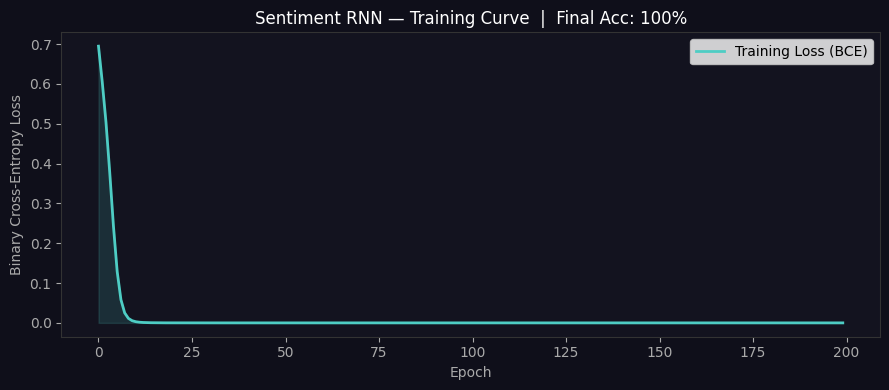


── Final Predictions ──
✅ 😊 POS (1.00) | 'I love this'
✅ 😊 POS (1.00) | 'great movie wonderful'
✅ 😊 POS (1.00) | 'amazing film loved it'
✅ 😊 POS (1.00) | 'fantastic brilliant superb'
✅ 😊 POS (1.00) | 'excellent fun enjoyed'
✅ 😢 NEG (0.00) | 'terrible awful film'
✅ 😢 NEG (0.00) | 'hated it boring bad'
✅ 😢 NEG (0.00) | 'worst movie ever seen'
✅ 😢 NEG (0.00) | 'dreadful horrible disgusting'
✅ 😢 NEG (0.00) | 'disappointed sad waste'

Overall Accuracy: 100%


In [29]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

torch.manual_seed(42)

# ── Tiny synthetic dataset ──
POS = ["I love this", "great movie wonderful", "amazing film loved it",
       "fantastic brilliant superb", "excellent fun enjoyed"]
NEG = ["terrible awful film", "hated it boring bad", "worst movie ever seen",
       "dreadful horrible disgusting", "disappointed sad waste"]

# Build vocabulary
all_words = " ".join(POS + NEG).split()
vocab = {w: i+1 for i,w in enumerate(set(all_words))}
vocab['<PAD>'] = 0

def encode(sentence, max_len=6):
    tokens = [vocab.get(w, 0) for w in sentence.split()]
    tokens = tokens[:max_len] + [0]*(max_len - len(tokens))
    return tokens

max_len = 6
X = torch.tensor([encode(s, max_len) for s in POS + NEG], dtype=torch.long)
y = torch.tensor([1]*5 + [0]*5, dtype=torch.float).unsqueeze(1)

# ── Model ──
class SentimentRNN(nn.Module):
    def __init__(self, vocab_size, embed_dim=16, hidden_dim=32):
        super().__init__()
        self.emb = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.rnn = nn.RNN(embed_dim, hidden_dim, batch_first=True,
                          bidirectional=True, num_layers=1)
        self.fc  = nn.Linear(hidden_dim * 2, 1)

    def forward(self, x):
        e = self.emb(x)
        _, h = self.rnn(e)        # h: (2, batch, hidden)
        ctx = torch.cat([h[0], h[1]], dim=1)
        return torch.sigmoid(self.fc(ctx))

model = SentimentRNN(vocab_size=len(vocab)+1)
optim = torch.optim.Adam(model.parameters(), lr=0.01)
loss_fn = nn.BCELoss()

# ── Training loop ──
losses = []
for epoch in range(200):
    model.train()
    pred  = model(X)
    loss  = loss_fn(pred, y)
    optim.zero_grad()
    loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
    optim.step()
    losses.append(loss.item())

# ── Final accuracy ──
model.eval()
with torch.no_grad():
    preds = model(X).squeeze()
    acc = ((preds > 0.5).float() == y.squeeze()).float().mean()

# ── Plot training curve ──
fig, ax = plt.subplots(figsize=(9, 4))
fig.patch.set_facecolor('#0f0f1a')
ax.set_facecolor('#13131f')
ax.plot(losses, color='#4ecdc4', lw=2, label='Training Loss (BCE)')
ax.fill_between(range(len(losses)), losses, alpha=0.15, color='#4ecdc4')
ax.set_xlabel('Epoch', color='#aaa')
ax.set_ylabel('Binary Cross-Entropy Loss', color='#aaa')
ax.set_title(f'Sentiment RNN — Training Curve  |  Final Acc: {acc:.0%}',
             color='white', fontsize=12)
ax.legend(fontsize=10)
ax.tick_params(colors='#aaa')
for sp in ax.spines.values(): sp.set_color('#333')
plt.tight_layout()
# plt.savefig('notes/assets/rnn_training_curve.png', dpi=150, bbox_inches='tight', facecolor='#0f0f1a')
plt.show()

# ── Predictions ──
print("\n── Final Predictions ──")
all_sentences = POS + NEG
with torch.no_grad():
    probs = model(X).squeeze().tolist()
for sentence, prob, label in zip(all_sentences, probs, [1]*5+[0]*5):
    pred_label = "😊 POS" if prob > 0.5 else "😢 NEG"
    correct = "✅" if (prob>0.5)==label else "❌"
    print(f"{correct} {pred_label} ({prob:.2f}) | '{sentence}'")
print(f"\nOverall Accuracy: {acc:.0%}")


## 9. 📋 RNN Issues — Complete Reference Table

| Issue | Root Cause | Mathematical Proof | Solution |
|---|---|---|---|
| **Vanishing Gradient** | $(W \cdot \tanh')^{T-k} \to 0$ when eigenvalues $<1$ | $\|\partial h_T / \partial h_k\| \leq \lambda_{max}^{T-k}$ | LSTM gates, GRU, ResNet-style skip connections |
| **Exploding Gradient** | $(V)^{T-k} \to \infty$ when eigenvalues $>1$ | Same product, $\lambda > 1$ | Gradient clipping ($\|g\| \leq \theta$) |
| **Short-Term Memory** | $h_t$ overwrites $h_{t-1}$ with no gating | No selective forget/keep mechanism in `tanh` | LSTM (Forget gate), GRU (Update gate) |
| **Sequential Bottleneck** | $h_t$ depends on $h_{t-1}$ → no time-dim parallelism | Dependency chain blocks GPU parallelism | Transformers (self-attention removes recurrence) |
| **Padding Artefacts** | RNN processes `<PAD>` tokens as real data | Hidden state gets "polluted" after EOS | `pack_padded_sequence` + `pad_packed_sequence` |

### Edge Cases to Know for Interviews

**1. Zero-length sequences / fully padded inputs**  
Always check input length before passing to RNN. Use `pack_padded_sequence`.

**2. Exploding at init (fresh model)**  
At random init, $V$ eigenvalues can be $>1$. Orthogonal initialisation keeps $|\lambda| = 1$ exactly.

**3. Gradient vanishing vs weight decay confusion**  
Weight decay (L2 regularisation) *intentionally* shrinks weights. This can **worsen** vanishing gradients in RNNs. Use with care.


#### 10. 🎯 Senior-Level Interview Q&A

---

**Q1: Explain vanishing gradients without using equations.**
 
> In an RNN, the gradient signal is repeatedly multiplied as it moves backward through time. If the weights are smaller than 1, each step slightly shrinks the signal. After many time steps, the gradient becomes almost zero.  
>  
> When this happens, early time steps receive almost no learning signal, so the model cannot learn long-range dependencies.


**Q2: Why can't we just increase the learning rate to compensate for vanishing gradients?**

> Increasing the learning rate scales the update applied to the gradient, but it does not change the gradient itself.  
>  
> In vanishing gradient problems, early time steps already receive gradients that are extremely close to zero. Multiplying a near-zero gradient by a larger learning rate still results in a very small update.  
>  
> Meanwhile, later time steps (which already have larger gradients) would receive excessively large updates, causing unstable training or divergence.  
>  
> In short, the problem is **not insufficient scaling**, but **loss of signal during backpropagation**, which a learning rate cannot fix.

**Key takeaway:**  
Learning rate affects **update magnitude**, not **gradient propagation**.

**Q3: What is the difference between BPTT and truncated BPTT? When would you use each?**

**Backpropagation Through Time (BPTT)** computes gradients across the **entire sequence**.

> The RNN is unrolled across all time steps, and gradients propagate from the final step back to the beginning.

Advantages:
- Exact gradient computation
- Captures full temporal dependencies

Disadvantages:
- High memory cost
- Computationally expensive
- Severe vanishing/exploding gradients for long sequences

**Truncated BPTT** limits how far gradients propagate.

> The sequence is divided into smaller windows, and gradients are only backpropagated a fixed number of time steps (for example 20–50).

Advantages:
- Much more memory efficient
- Faster training
- More stable gradients

Disadvantages:
- Cannot capture extremely long dependencies.

**Typical use cases**

- language modeling
- long documents
- financial time-series
- reinforcement learning sequences

**Q4: Can a unidirectional RNN be used for machine translation?**

> Yes, but not by itself.

In the classic **seq2seq architecture**, two RNNs are used:

**Encoder**
- Reads the entire source sentence
- Produces a context representation

**Decoder**
- Generates the translated sentence token by token

The decoder must be **unidirectional** because it generates words sequentially and cannot see future tokens.

However, using only a single unidirectional RNN without an encoder–decoder structure would perform poorly because translation requires understanding the **entire source sentence before generating output**.

**Modern systems** replace RNNs with **Transformers**, which capture global context using attention.

**Q5: What does `pack_padded_sequence` do and why is it important?**

When batching sequences of different lengths, shorter sequences are padded with `<PAD>` tokens.

If we feed padded sequences directly into an RNN:

- the RNN continues updating hidden states for padded tokens
- this introduces **noise into the hidden representation**

`pack_padded_sequence` tells PyTorch:

> "Ignore padded tokens and only process the valid portion of each sequence."

Benefits:

- avoids unnecessary computation
- prevents hidden state contamination
- improves model accuracy
- speeds up training

It is especially important in tasks like:

- text classification
- speech recognition
- sequence tagging

**Q6: Why do we initialize the hidden state \(h_0\) to zeros?**

The hidden state represents the **memory of the sequence processed so far**.

At the beginning of a new sequence:

- no information has been seen yet
- therefore the most neutral starting point is a **zero vector**

This provides a consistent starting condition across all sequences.

However, in some architectures:

- the initial hidden state can be **learned as a parameter**
- or initialized using **context from another network** (e.g., encoder → decoder in seq2seq models)

For most standard RNN applications, zero initialization works well and is the common default.